=== 肿瘤抗原预测模型训练与特征筛选 (SVM版本) ===
1. 加载训练数据...
成功加载 167642 条序列
正样本: 50308, 负样本: 117334

2. 提取特征...
成功加载 20 种氨基酸的物化性质
正在为 167642 个序列提取特征...
已处理 1000/167642 个序列
已处理 2000/167642 个序列
已处理 3000/167642 个序列
已处理 4000/167642 个序列
已处理 5000/167642 个序列
已处理 6000/167642 个序列
已处理 7000/167642 个序列
已处理 8000/167642 个序列
已处理 9000/167642 个序列
已处理 10000/167642 个序列
已处理 11000/167642 个序列
已处理 12000/167642 个序列
已处理 13000/167642 个序列
已处理 14000/167642 个序列
已处理 15000/167642 个序列
已处理 16000/167642 个序列
已处理 17000/167642 个序列
已处理 18000/167642 个序列
已处理 19000/167642 个序列
已处理 20000/167642 个序列
已处理 21000/167642 个序列
已处理 22000/167642 个序列
已处理 23000/167642 个序列
已处理 24000/167642 个序列
已处理 25000/167642 个序列
已处理 26000/167642 个序列
已处理 27000/167642 个序列
已处理 28000/167642 个序列
已处理 29000/167642 个序列
已处理 30000/167642 个序列
已处理 31000/167642 个序列
已处理 32000/167642 个序列
已处理 33000/167642 个序列
已处理 34000/167642 个序列
已处理 35000/167642 个序列
已处理 36000/167642 个序列
已处理 37000/167642 个序列
已处理 38000/167642 个序列
已处理 39000/167642 个序列
已处理 40000/167642 个序列
已处理 41000/167642 个序列
已处理 42000/1

<Figure size 1200x800 with 0 Axes>

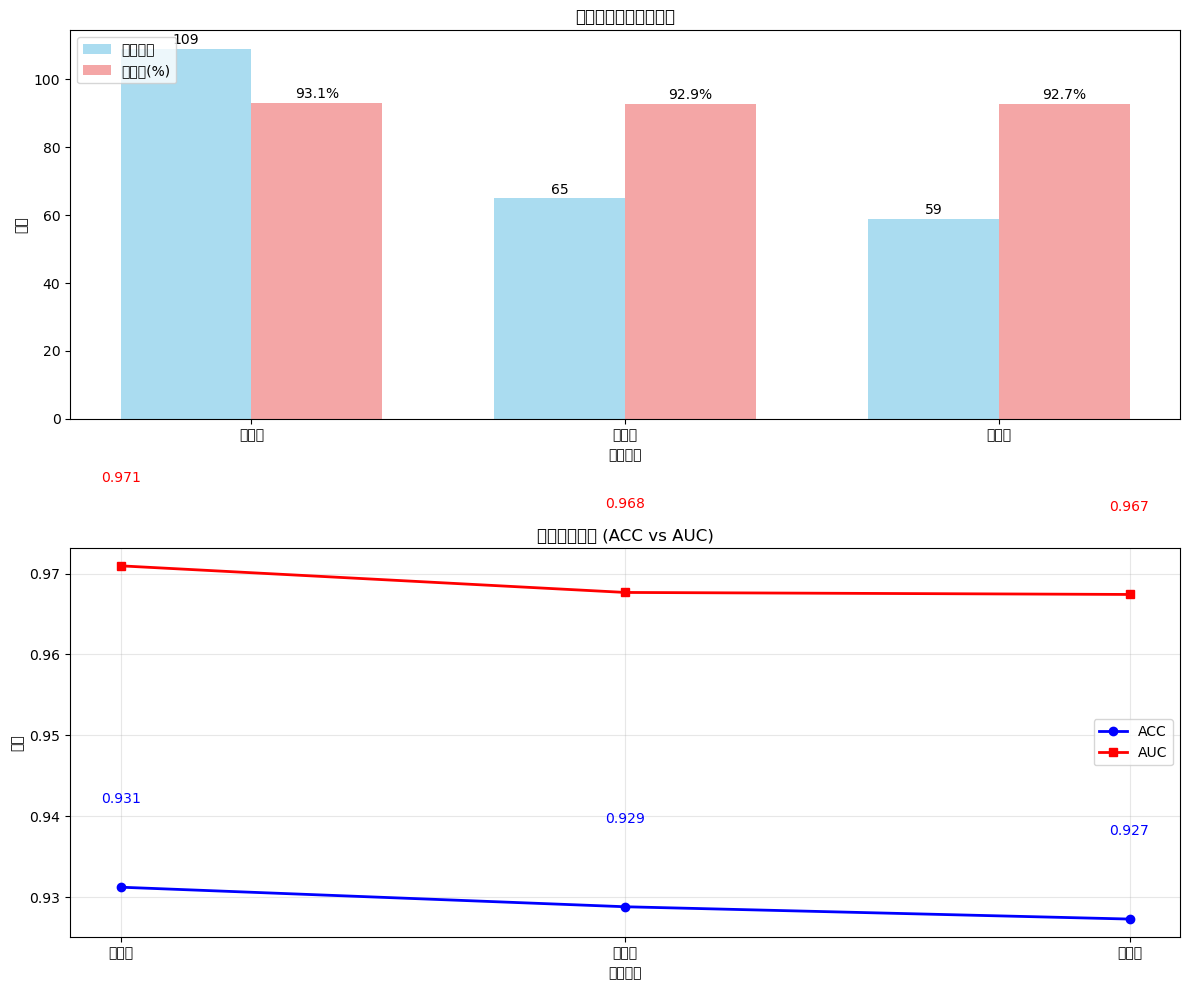

模型已保存到: tumor_svm_model_final.joblib
标准化器已保存到: tumor_scaler_final.joblib
最终特征列表已保存: final_selected_features.txt
特征筛选报告已保存: feature_selection_report.txt

特征筛选完成 - 最终结果 (SVM版本)
初始特征数: 109
最终特征数: 109
特征精简率: 0.0%

最终SVM模型性能:
  - 准确率 (ACC): 0.9313
  - AUC: 0.9710

性能提升:
  - ACC 提升: +0.00%
  - AUC 提升: +0.00%

最终特征构成分析:
  基础序列特征: 1个特征, 重要性占比 11.2%
  氨基酸编码特征: 9个特征, 重要性占比 7.3%
  氨基酸组成特征: 20个特征, 重要性占比 10.3%
  物化统计特征: 18个特征, 重要性占比 26.1%
  位置特异性物化特征: 20个特征, 重要性占比 16.6%

文件输出:
  - 最终SVM模型: tumor_svm_model_final.joblib
  - 标准化器: tumor_scaler_final.joblib
  - 特征列表: final_selected_features.txt
  - 特征重要性: feature_importance_final.csv
  - 性能对比图: feature_selection_performance.png
  - 筛选报告: feature_selection_report.txt


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from joblib import dump
import os
import warnings
warnings.filterwarnings('ignore')

print("=== 肿瘤抗原预测模型训练与特征筛选 (SVM版本) ===")

class TumorFeatureExtractor:
    def __init__(self, acid_file_path='acid.xlsx'):
        self.feature_names = []
        self.amino_acid_encoding = {
            'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
            'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'S': 16, 'T': 17, 'W': 18, 'Y': 19, 'V': 20
        }
        
        # 加载氨基酸物化性质表
        self.acid_properties = self._load_acid_properties(acid_file_path)
        print(f"成功加载 {len(self.acid_properties)} 种氨基酸的物化性质")
    
    def _load_acid_properties(self, file_path):
        try:
            df = pd.read_excel(file_path)
            df.columns = [col.strip() for col in df.columns]
            df['acid'] = df['acid'].astype(str).str.strip()
            
            properties_dict = {}
            for _, row in df.iterrows():
                acid = row['acid']
                properties_dict[acid] = {
                    'hydrophobicity': row['Hydrophobicity'],
                    'pI': row['pI'],
                    'MW': row['MW'],
                    'ele': row['ele'],
                    'plo': row['plo'],
                    'hydrocapto': row['Hydrocapto']  # 修复：首字母大写
                }
            return properties_dict
        except Exception as e:
            print(f"加载氨基酸性质文件失败: {e}")
            return {}
    
    def extract_features(self, sequences):
        if not sequences:
            raise ValueError("序列列表为空")
        
        print(f"正在为 {len(sequences)} 个序列提取特征...")
        features_list = []
        
        for i, seq in enumerate(sequences):
            if i % 1000 == 0 and i > 0:
                print(f"已处理 {i}/{len(sequences)} 个序列")
            
            features = self._extract_single_sequence_features(seq)
            features_list.append(features)
        
        feature_df = pd.DataFrame(features_list)
        self.feature_names = feature_df.columns.tolist()
        
        print(f"特征提取完成，共生成 {len(self.feature_names)} 个特征")
        return feature_df
    
    def _extract_single_sequence_features(self, sequence):
        features = {}
        
        # 基础序列特征
        features['sequence_length'] = len(sequence)
        
        # 使用acid.xlsx中的物化性质计算特征
        features.update(self._calculate_acid_based_features(sequence))
        
        # 简化的物化特征（已删除6个指定特征）
        features.update(self._calculate_simple_features(sequence))
        
        # 氨基酸组成特征
        features.update(self._calculate_aa_composition(sequence))
        
        # 位置特异性特征
        features.update(self._calculate_position_features(sequence))
        
        # 氨基酸编码特征
        features.update(self._calculate_encoding_features(sequence))
        
        # 位置特异性物化特征（新增54个特征）
        features.update(self._calculate_position_specific_acid_features(sequence))
        
        return features
    
    def _calculate_acid_based_features(self, sequence):
        features = {}
        sequence_upper = sequence.upper()
        
        if not self.acid_properties:
            return features
        
        # 为6个物化特性分别创建值列表
        hydrophobicity_values = []
        pi_values = []
        mw_values = []
        ele_values = []
        plo_values = []
        hydrocapto_values = []
        
        for aa in sequence_upper:
            if aa in self.acid_properties:
                props = self.acid_properties[aa]
                hydrophobicity_values.append(props['hydrophobicity'])
                pi_values.append(props['pI'])
                mw_values.append(props['MW'])
                ele_values.append(props['ele'])
                plo_values.append(props['plo'])
                hydrocapto_values.append(props['hydrocapto'])
        
        # 为每个物化特性计算平均值、标准差、总和（共6×3=18个特征）
        # Hydrophobicity
        if hydrophobicity_values:
            features['avg_Hydrophobicity'] = np.mean(hydrophobicity_values)
            features['std_Hydrophobicity'] = np.std(hydrophobicity_values)
            features['total_Hydrophobicity'] = np.sum(hydrophobicity_values)
        
        # pI
        if pi_values:
            features['avg_pI'] = np.mean(pi_values)
            features['std_pI'] = np.std(pi_values)
            features['total_pI'] = np.sum(pi_values)
        
        # MW
        if mw_values:
            features['avg_MW'] = np.mean(mw_values)
            features['std_MW'] = np.std(mw_values)
            features['total_MW'] = np.sum(mw_values)
        
        # ele
        if ele_values:
            features['avg_ele'] = np.mean(ele_values)
            features['std_ele'] = np.std(ele_values)
            features['total_ele'] = np.sum(ele_values)
        
        # plo
        if plo_values:
            features['avg_plo'] = np.mean(plo_values)
            features['std_plo'] = np.std(plo_values)
            features['total_plo'] = np.sum(plo_values)
        
        # Hydrocapto
        if hydrocapto_values:
            features['avg_Hydrocapto'] = np.mean(hydrocapto_values)
            features['std_Hydrocapto'] = np.std(hydrocapto_values)
            features['total_Hydrocapto'] = np.sum(hydrocapto_values)
        
        return features
    
    def _calculate_simple_features(self, sequence):
        features = {}
        # 已删除6个简单特征
        return features
    
    def _calculate_aa_composition(self, sequence):
        composition = {}
        total_length = len(sequence)
        sequence_upper = sequence.upper()
        
        if total_length == 0:
            return composition
        
        for aa in self.amino_acid_encoding.keys():
            count = sequence_upper.count(aa)
            composition[f'{aa}_composition'] = count / total_length
        
        return composition
    
    def _calculate_position_features(self, sequence, max_length=9):
        features = {}
        
        features['P2_L'] = 1 if len(sequence) > 1 and sequence[1].upper() == 'L' else 0
        features['P3_L_neg'] = 1 if len(sequence) > 2 and sequence[2].upper() == 'L' else 0
        features['P4_LVI'] = 1 if len(sequence) > 3 and sequence[3].upper() in {'L', 'V', 'I'} else 0
        features['P9_L'] = 1 if len(sequence) > 8 and sequence[8].upper() == 'L' else 0
        features['P9_V'] = 1 if len(sequence) > 8 and sequence[8].upper() == 'V' else 0
        features['P6_L'] = 1 if len(sequence) > 5 and sequence[5].upper() == 'L' else 0
        features['P7-8_LVI_neg'] = 1 if (
            (len(sequence) > 6 and sequence[6].upper() in {'L', 'V', 'I'}) or 
            (len(sequence) > 7 and sequence[7].upper() in {'L', 'V', 'I'})
        ) else 0
        
        return features
    
    def _calculate_encoding_features(self, sequence, max_length=9):
        features = {}
        
        encoded = [self.amino_acid_encoding.get(aa.upper(), 0) for aa in sequence[:max_length]]
        encoded += [0] * (max_length - len(encoded))
        
        for i in range(max_length):
            features[f'AA{i+1}'] = encoded[i]
        
        return features
    
    def _calculate_position_specific_acid_features(self, sequence, max_length=9):
        """计算位置特异性物化特征（新增54个特征）"""
        features = {}
        sequence_upper = sequence.upper()
        
        # 为每个位置计算6个物化特性值
        for i in range(max_length):
            if i < len(sequence_upper):
                aa = sequence_upper[i]
                if aa in self.acid_properties:
                    props = self.acid_properties[aa]
                    features[f'P{i+1}_Hydrophobicity'] = props['hydrophobicity']
                    features[f'P{i+1}_pI'] = props['pI']
                    features[f'P{i+1}_MW'] = props['MW']
                    features[f'P{i+1}_ele'] = props['ele']
                    features[f'P{i+1}_plo'] = props['plo']
                    features[f'P{i+1}_Hydrocapto'] = props['hydrocapto']
                else:
                    # 如果氨基酸不在acid表中，用0填充
                    features[f'P{i+1}_Hydrophobicity'] = 0
                    features[f'P{i+1}_pI'] = 0
                    features[f'P{i+1}_MW'] = 0
                    features[f'P{i+1}_ele'] = 0
                    features[f'P{i+1}_plo'] = 0
                    features[f'P{i+1}_Hydrocapto'] = 0
            else:
                # 如果序列长度不足，用0填充
                features[f'P{i+1}_Hydrophobicity'] = 0
                features[f'P{i+1}_pI'] = 0
                features[f'P{i+1}_MW'] = 0
                features[f'P{i+1}_ele'] = 0
                features[f'P{i+1}_plo'] = 0
                features[f'P{i+1}_Hydrocapto'] = 0
        
        return features
    
    def get_feature_names(self):
        return self.feature_names

class SVMModel:
    """SVM模型类"""
    
    def __init__(self, kernel='rbf', C=1.0, gamma='scale', probability=True):
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.probability = probability
        self.model = None
        self.scaler = None
    
    def build_model(self):
        """构建SVM模型"""
        self.model = SVC(
            kernel=self.kernel,
            C=self.C,
            gamma=self.gamma,
            probability=self.probability,
            random_state=42
        )
        return self.model
    
    def train(self, X_train, y_train, verbose=1):
        """训练模型"""
        # 标准化数据
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        
        # 训练SVM模型
        self.model.fit(X_train_scaled, y_train)
        
        if verbose:
            print("SVM模型训练完成")
        
        return self.model
    
    def predict(self, X):
        """预测"""
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)
    
    def predict_proba(self, X):
        """预测概率"""
        X_scaled = self.scaler.transform(X)
        return self.model.predict_proba(X_scaled)
    
    def evaluate(self, X, y):
        """评估模型"""
        X_scaled = self.scaler.transform(X)
        y_pred = self.model.predict(X_scaled)
        accuracy = accuracy_score(y, y_pred)
        return accuracy
    
    def save_model(self, model_filepath, scaler_filepath):
        """保存模型和标准化器"""
        dump(self.model, model_filepath)
        dump(self.scaler, scaler_filepath)
        print(f"模型已保存到: {model_filepath}")
        print(f"标准化器已保存到: {scaler_filepath}")

class FeatureSelector:
    """特征筛选器"""
    
    def __init__(self):
        self.selection_log = []
    
    def stage1_importance_filter(self, feature_importance_df, threshold_ratio=0.6):
        """第一阶段：基于特征重要性初筛"""
        print("\n" + "="*60)
        print("STEP 1: 基于特征重要性的初筛")
        print("="*60)
        
        # 设定筛选阈值
        threshold_rank = int(len(feature_importance_df) * threshold_ratio)
        threshold_importance = 1 / len(feature_importance_df)  # 平均重要性
        
        print(f"初筛阈值设定:")
        print(f"  - 排名前 {threshold_ratio*100}% (rank ≤ {threshold_rank})")
        print(f"  - 重要性 > 平均值 ({threshold_importance:.6f})")
        
        # 筛选符合条件的特征
        selected_features = []
        for _, row in feature_importance_df.iterrows():
            if row['rank'] <= threshold_rank or row['importance'] > threshold_importance:
                selected_features.append(row['feature'])
        
        # 记录筛选结果
        self.selection_log.append({
            'stage': '初筛',
            'method': '特征重要性',
            'threshold': f'排名前{threshold_ratio*100}% + 重要性>均值',
            'input_features': len(feature_importance_df),
            'output_features': len(selected_features),
            'removed_features': len(feature_importance_df) - len(selected_features)
        })
        
        print(f"初筛结果:")
        print(f"  - 筛选前特征数: {len(feature_importance_df)}")
        print(f"  - 筛选后特征数: {len(selected_features)}")
        print(f"  - 剔除特征数: {len(feature_importance_df) - len(selected_features)}")
        print(f"  - 保留率: {len(selected_features)/len(feature_importance_df)*100:.1f}%")
        
        return selected_features
    
    def stage2_statistical_filter(self, X_df, selected_features, feature_importance_df, 
                                 variance_threshold=0.01, correlation_threshold=0.8):
        """第二阶段：统计型精筛"""
        print("\n" + "="*60)
        print("STEP 2: 统计型精筛（方差阈值 + 相关系数）")
        print("="*60)
        
        # 提取初筛后的特征数据
        X_stage1 = X_df[selected_features].copy()
        
        # 2.1 方差阈值筛选
        print("2.1 方差阈值筛选...")
        vt = VarianceThreshold(threshold=variance_threshold)
        X_vt = vt.fit_transform(X_stage1)
        selected_features_vt = X_stage1.columns[vt.get_support()].tolist()
        
        print(f"  - 方差筛选前: {len(selected_features)} 个特征")
        print(f"  - 方差筛选后: {len(selected_features_vt)} 个特征")
        print(f"  - 剔除无效特征: {len(selected_features) - len(selected_features_vt)} 个")
        
        # 2.2 相关系数筛选
        print("2.2 相关系数筛选...")
        X_vt_df = pd.DataFrame(X_vt, columns=selected_features_vt)
        corr_matrix = X_vt_df.corr().abs()  # 取绝对值
        
        selected_features_stage2 = []
        dropped_features = []
        
        for i in range(len(corr_matrix.columns)):
            feature_i = corr_matrix.columns[i]
            if feature_i in selected_features_stage2:
                continue
            
            selected_features_stage2.append(feature_i)
            
            for j in range(i+1, len(corr_matrix.columns)):
                feature_j = corr_matrix.columns[j]
                if feature_j in selected_features_stage2:
                    continue
                    
                corr_value = corr_matrix.iloc[i, j]
                if corr_value > correlation_threshold:
                    # 获取特征重要性
                    imp_i = feature_importance_df[feature_importance_df['feature'] == feature_i]['importance'].values[0]
                    imp_j = feature_importance_df[feature_importance_df['feature'] == feature_j]['importance'].values[0]
                    
                    # 保留重要性更高的特征
                    if imp_j > imp_i:
                        selected_features_stage2.remove(feature_i)
                        selected_features_stage2.append(feature_j)
                        dropped_features.append((feature_i, feature_j, corr_value, imp_i, imp_j))
                        break
                    else:
                        dropped_features.append((feature_j, feature_i, corr_value, imp_j, imp_i))
        
        # 记录筛选结果
        self.selection_log.append({
            'stage': '精筛',
            'method': '方差阈值+相关系数',
            'threshold': f'方差>{variance_threshold}, r>{correlation_threshold}',
            'input_features': len(selected_features),
            'output_features': len(selected_features_stage2),
            'removed_features': len(selected_features) - len(selected_features_stage2)
        })
        
        print(f"精筛结果:")
        print(f"  - 筛选前特征数: {len(selected_features)}")
        print(f"  - 筛选后特征数: {len(selected_features_stage2)}")
        print(f"  - 剔除冗余特征: {len(selected_features) - len(selected_features_stage2)}")
        
        if dropped_features:
            print(f"  - 主要冗余特征对 (前5个):")
            for i, (feat_drop, feat_keep, corr, imp_drop, imp_keep) in enumerate(dropped_features[:5]):
                print(f"    {feat_drop} (imp:{imp_drop:.4f}) vs {feat_keep} (imp:{imp_keep:.4f}) - r={corr:.3f}")
        
        return selected_features_stage2
    
    def stage3_performance_validation(self, X_full, y, feature_sets, feature_names):
        """第三阶段：性能验证闭环"""
        print("\n" + "="*60)
        print("STEP 3: 性能验证闭环")
        print("="*60)
        
        results = {}
        
        for set_name, features in feature_sets.items():
            print(f"训练 {set_name} SVM模型...")
            X_subset = X_full[features]
            
            # 数据划分
            X_train, X_test, y_train, y_test = train_test_split(
                X_subset, y, test_size=0.2, random_state=42, stratify=y
            )
            
            # 训练SVM模型
            svm_model = SVMModel(kernel='rbf', C=1.0, gamma='scale', probability=True)
            svm_model.build_model()
            svm_model.train(X_train, y_train, verbose=0)
            
            # 评估
            y_prob = svm_model.predict_proba(X_test)[:, 1]
            y_pred = svm_model.predict(X_test)
            
            acc = accuracy_score(y_test, y_pred)
            auc = roc_auc_score(y_test, y_prob)
            
            results[set_name] = {
                'feature_count': len(features),
                'ACC': acc,
                'AUC': auc,
                'model': svm_model,
                'features': features
            }
            
            print(f"  - {set_name}: {len(features)}个特征, ACC={acc:.4f}, AUC={auc:.4f}")
        
        return results
    
    def plot_performance_comparison(self, results, save_path='feature_selection_performance.png'):
        """绘制性能对比图"""
        plt.figure(figsize=(12, 8))
        
        # 提取数据
        labels = list(results.keys())
        feature_counts = [results[label]['feature_count'] for label in labels]
        acc_scores = [results[label]['ACC'] for label in labels]
        auc_scores = [results[label]['AUC'] for label in labels]
        
        # 创建子图
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # 柱状图 - 特征数量和准确率
        x = np.arange(len(labels))
        width = 0.35
        
        bars1 = ax1.bar(x - width/2, feature_counts, width, label='特征数量', alpha=0.7, color='skyblue')
        bars2 = ax1.bar(x + width/2, [acc * 100 for acc in acc_scores], width, label='准确率(%)', alpha=0.7, color='lightcoral')
        
        ax1.set_xlabel('特征组合')
        ax1.set_ylabel('数值')
        ax1.set_title('特征数量与准确率对比')
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels)
        ax1.legend(loc='upper left')
        
        # 在柱状图上添加数值标签
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{int(height)}', ha='center', va='bottom')
        
        for bar in bars2:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom')
        
        # 折线图 - AUC和准确率
        ax2.plot(labels, acc_scores, marker='o', linewidth=2, label='ACC', color='blue')
        ax2.plot(labels, auc_scores, marker='s', linewidth=2, label='AUC', color='red')
        ax2.set_xlabel('特征组合')
        ax2.set_ylabel('分数')
        ax2.set_title('模型性能对比 (ACC vs AUC)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 在折线图上添加数值标签
        for i, (acc, auc) in enumerate(zip(acc_scores, auc_scores)):
            ax2.text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom', color='blue')
            ax2.text(i, auc + 0.01, f'{auc:.3f}', ha='center', va='bottom', color='red')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"性能对比图已保存: {save_path}")
        plt.show()
    
    def save_final_features(self, final_features, save_path='final_selected_features.txt'):
        """保存最终特征列表"""
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write("# 最终筛选的特征列表\n")
            for feature in final_features:
                f.write(feature + '\n')
        print(f"最终特征列表已保存: {save_path}")
    
    def generate_selection_report(self, save_path='feature_selection_report.txt'):
        """生成特征筛选报告"""
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write("=== 肿瘤抗原预测特征筛选报告 (SVM版本) ===\n\n")
            
            for log in self.selection_log:
                f.write(f"{log['stage']}阶段:\n")
                f.write(f"  方法: {log['method']}\n")
                f.write(f"  阈值: {log['threshold']}\n")
                f.write(f"  输入特征数: {log['input_features']}\n")
                f.write(f"  输出特征数: {log['output_features']}\n")
                f.write(f"  剔除特征数: {log['removed_features']}\n")
                f.write(f"  保留率: {log['output_features']/log['input_features']*100:.1f}%\n\n")
        
        print(f"特征筛选报告已保存: {save_path}")

def calculate_feature_importance(X, y, feature_names, output_file='feature_importance.csv'):
    """计算并保存特征重要性（使用简单的随机森林作为特征重要性评估器）"""
    print(f"\n计算特征重要性...")
    
    from sklearn.ensemble import RandomForestClassifier
    
    # 使用随机森林计算特征重要性
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # 获取特征重要性
    importances = rf.feature_importances_
    
    # 创建特征重要性DataFrame
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    
    # 按重要性排序
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
    
    # 添加排名
    feature_importance_df['rank'] = range(1, len(feature_importance_df) + 1)
    
    # 计算累积重要性
    feature_importance_df['cumulative_importance'] = feature_importance_df['importance'].cumsum()
    
    # 保存到CSV文件
    feature_importance_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"特征重要性已保存到: {output_file}")
    
    # 显示最重要的10个特征
    print("\n最重要的10个特征:")
    print(feature_importance_df.head(10)[['rank', 'feature', 'importance']].to_string(index=False))
    
    return feature_importance_df

def main():
    # 检查文件
    if not os.path.exists('acid.xlsx'):
        print("错误: 未找到 acid.xlsx 文件")
        return
    
    if not os.path.exists('A0201_160000.xlsx'):
        print("错误: 未找到 A0201_160000.xlsx 文件")
        return
    
    try:
        # 1. 加载数据
        print("1. 加载训练数据...")
        dataset = pd.read_excel('A0201_160000.xlsx', na_filter=False)
        print(f"成功加载 {len(dataset)} 条序列")
        print(f"正样本: {sum(dataset['label'])}, 负样本: {len(dataset) - sum(dataset['label'])}")
        
        # 2. 提取特征
        print("\n2. 提取特征...")
        extractor = TumorFeatureExtractor('acid.xlsx')
        feature_df = extractor.extract_features(dataset['sequence'].tolist())
        X = feature_df
        y = dataset['label'].values
        
        print(f"特征矩阵形状: {X.shape}")
        print(f"总特征数量: {len(extractor.feature_names)}")
        
        # 3. 训练全特征SVM模型作为基准
        print("\n3. 训练全特征SVM基准模型...")
        X_train_full, X_test_full, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # 训练SVM模型
        svm_model_full = SVMModel(kernel='rbf', C=1.0, gamma='scale', probability=True)
        svm_model_full.build_model()
        svm_model_full.train(X_train_full, y_train)
        
        # 评估全特征模型
        y_prob_full = svm_model_full.predict_proba(X_test_full)[:, 1]
        y_pred_full = svm_model_full.predict(X_test_full)
        
        acc_full = accuracy_score(y_test, y_pred_full)
        auc_full = roc_auc_score(y_test, y_prob_full)
        
        print(f"全特征SVM模型性能:")
        print(f"  - 准确率 (ACC): {acc_full:.4f}")
        print(f"  - AUC: {auc_full:.4f}")
        
        # 4. 计算特征重要性（使用随机森林作为评估器）
        feature_importance_df = calculate_feature_importance(
            X_train_full, y_train, extractor.feature_names, 'feature_importance_109.csv'
        )
        
        # 5. 特征筛选流程
        print("\n" + "="*80)
        print("开始三阶段特征筛选流程")
        print("="*80)
        
        selector = FeatureSelector()
        
        # Stage 1: 重要性初筛
        features_stage1 = selector.stage1_importance_filter(feature_importance_df, threshold_ratio=0.6)
        
        # Stage 2: 统计精筛
        features_stage2 = selector.stage2_statistical_filter(
            X, features_stage1, feature_importance_df,
            variance_threshold=0.01, correlation_threshold=0.8
        )
        
        # 基于性能验证选择最优特征集
        print("\n" + "="*60)
        print("基于性能验证选择最优特征集")
        print("="*60)
        
        # 性能验证：比较不同特征集的性能
        feature_sets = {
            '全特征': extractor.feature_names,
            '初筛后': features_stage1,
            '精筛后': features_stage2
        }
        
        performance_results = selector.stage3_performance_validation(X, y, feature_sets, extractor.feature_names)
        
        # 基于性能选择最优特征集
        best_performance = -1
        best_feature_set = None
        best_features = None
        
        for set_name, result in performance_results.items():
            performance_score = result['ACC'] + result['AUC']  # 综合评分
            if performance_score > best_performance:
                best_performance = performance_score
                best_feature_set = set_name
                best_features = result['features']
        
        print(f"\n性能最优的特征集: {best_feature_set}")
        print(f"  - 特征数: {len(best_features)}")
        print(f"  - ACC: {performance_results[best_feature_set]['ACC']:.4f}")
        print(f"  - AUC: {performance_results[best_feature_set]['AUC']:.4f}")
        
        # 使用性能最优的特征集作为最终特征
        features_final = best_features
        final_model = performance_results[best_feature_set]['model']
        
        # 6. 性能对比可视化
        selector.plot_performance_comparison(performance_results)
        
        # 7. 保存最终结果
        # 保存模型和预处理对象
        final_model.save_model('tumor_svm_model_final.joblib', 'tumor_scaler_final.joblib')
        
        # 保存特征列表和报告
        selector.save_final_features(features_final)
        selector.generate_selection_report()
        
        # 保存最终特征的重要性
        final_importance_df = feature_importance_df[feature_importance_df['feature'].isin(features_final)].copy()
        final_importance_df = final_importance_df.sort_values('importance', ascending=False)
        final_importance_df.to_csv('feature_importance_final.csv', index=False, encoding='utf-8-sig')
        
        # 8. 最终报告
        print("\n" + "="*80)
        print("特征筛选完成 - 最终结果 (SVM版本)")
        print("="*80)
        
        print(f"初始特征数: {len(extractor.feature_names)}")
        print(f"最终特征数: {len(features_final)}")
        print(f"特征精简率: {(1 - len(features_final)/len(extractor.feature_names))*100:.1f}%")
        
        final_perf = performance_results[best_feature_set]
        print(f"\n最终SVM模型性能:")
        print(f"  - 准确率 (ACC): {final_perf['ACC']:.4f}")
        print(f"  - AUC: {final_perf['AUC']:.4f}")
        
        improvement_acc = (final_perf['ACC'] - acc_full) * 100
        improvement_auc = (final_perf['AUC'] - auc_full) * 100
        
        print(f"\n性能提升:")
        print(f"  - ACC 提升: {improvement_acc:+.2f}%")
        print(f"  - AUC 提升: {improvement_auc:+.2f}%")
        
        # 特征类别分析
        feature_categories = {
            "基础序列特征": [f for f in features_final if f == 'sequence_length'],
            "氨基酸编码特征": [f for f in features_final if f.startswith('AA')],
            "氨基酸组成特征": [f for f in features_final if f.endswith('_composition')],
            "位置特异性特征": [f for f in features_final if f.startswith('P') and len(f) <= 10 and not '_' in f],
            "物化统计特征": [f for f in features_final if any(x in f for x in ['avg_', 'std_', 'total_']) and not f.startswith('P')],
            "位置特异性物化特征": [f for f in features_final if f.startswith('P') and '_' in f and len(f) > 10]
        }
        
        print(f"\n最终特征构成分析:")
        for category, features in feature_categories.items():
            if features:
                category_importance = final_importance_df[
                    final_importance_df['feature'].isin(features)
                ]['importance'].sum()
                total_importance = final_importance_df['importance'].sum()
                print(f"  {category}: {len(features)}个特征, 重要性占比 {category_importance/total_importance*100:.1f}%")
        
        print(f"\n文件输出:")
        print(f"  - 最终SVM模型: tumor_svm_model_final.joblib")
        print(f"  - 标准化器: tumor_scaler_final.joblib")
        print(f"  - 特征列表: final_selected_features.txt")
        print(f"  - 特征重要性: feature_importance_final.csv")
        print(f"  - 性能对比图: feature_selection_performance.png")
        print(f"  - 筛选报告: feature_selection_report.txt")
        
    except Exception as e:
        print(f"训练过程中出错: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [2]:
import pandas as pd
import numpy as np
from joblib import load
import os

print("=== 肿瘤抗原预测（使用SVM和特征筛选） ===")

class TumorFeatureExtractor:
    def __init__(self, acid_file_path='acid.xlsx'):
        self.feature_names = []
        self.amino_acid_encoding = {
            'A': 1, 'R': 2, 'N': 3, 'D': 4, 'C': 5, 'Q': 6, 'E': 7, 'G': 8, 'H': 9, 'I': 10,
            'L': 11, 'K': 12, 'M': 13, 'F': 14, 'P': 15, 'S': 16, 'T': 17, 'W': 18, 'Y': 19, 'V': 20
        }
        
        # 加载氨基酸物化性质表
        self.acid_properties = self._load_acid_properties(acid_file_path)
        print(f"成功加载 {len(self.acid_properties)} 种氨基酸的物化性质")
    
    def _load_acid_properties(self, file_path):
        try:
            df = pd.read_excel(file_path)
            df.columns = [col.strip() for col in df.columns]
            df['acid'] = df['acid'].astype(str).str.strip()
            
            properties_dict = {}
            for _, row in df.iterrows():
                acid = row['acid']
                properties_dict[acid] = {
                    'hydrophobicity': row['Hydrophobicity'],
                    'pI': row['pI'],
                    'MW': row['MW'],
                    'ele': row['ele'],
                    'plo': row['plo'],
                    'hydrocapto': row['Hydrocapto']  # 修复：首字母大写
                }
            return properties_dict
        except Exception as e:
            print(f"加载氨基酸性质文件失败: {e}")
            return {}
    
    def extract_features(self, sequences):
        if not sequences:
            raise ValueError("序列列表为空")
        
        print(f"正在为 {len(sequences)} 个序列提取特征...")
        features_list = []
        
        for i, seq in enumerate(sequences):
            if i % 1000 == 0 and i > 0:
                print(f"已处理 {i}/{len(sequences)} 个序列")
            
            features = self._extract_single_sequence_features(seq)
            features_list.append(features)
        
        feature_df = pd.DataFrame(features_list)
        self.feature_names = feature_df.columns.tolist()
        
        print(f"特征提取完成，共生成 {len(self.feature_names)} 个特征")
        return feature_df
    
    def _extract_single_sequence_features(self, sequence):
        features = {}
        
        # 基础序列特征
        features['sequence_length'] = len(sequence)
        
        # 使用acid.xlsx中的物化性质计算特征
        features.update(self._calculate_acid_based_features(sequence))
        
        # 简化的物化特征（已删除6个指定特征）
        features.update(self._calculate_simple_features(sequence))
        
        # 氨基酸组成特征
        features.update(self._calculate_aa_composition(sequence))
        
        # 位置特异性特征
        features.update(self._calculate_position_features(sequence))
        
        # 氨基酸编码特征
        features.update(self._calculate_encoding_features(sequence))
        
        # 位置特异性物化特征（新增54个特征）
        features.update(self._calculate_position_specific_acid_features(sequence))
        
        return features
    
    def _calculate_acid_based_features(self, sequence):
        features = {}
        sequence_upper = sequence.upper()
        
        if not self.acid_properties:
            return features
        
        # 为6个物化特性分别创建值列表
        hydrophobicity_values = []
        pi_values = []
        mw_values = []
        ele_values = []
        plo_values = []
        hydrocapto_values = []
        
        for aa in sequence_upper:
            if aa in self.acid_properties:
                props = self.acid_properties[aa]
                hydrophobicity_values.append(props['hydrophobicity'])
                pi_values.append(props['pI'])
                mw_values.append(props['MW'])
                ele_values.append(props['ele'])
                plo_values.append(props['plo'])
                hydrocapto_values.append(props['hydrocapto'])
        
        # 为每个物化特性计算平均值、标准差、总和（共6×3=18个特征）
        # Hydrophobicity
        if hydrophobicity_values:
            features['avg_Hydrophobicity'] = np.mean(hydrophobicity_values)
            features['std_Hydrophobicity'] = np.std(hydrophobicity_values)
            features['total_Hydrophobicity'] = np.sum(hydrophobicity_values)
        
        # pI
        if pi_values:
            features['avg_pI'] = np.mean(pi_values)
            features['std_pI'] = np.std(pi_values)
            features['total_pI'] = np.sum(pi_values)
        
        # MW
        if mw_values:
            features['avg_MW'] = np.mean(mw_values)
            features['std_MW'] = np.std(mw_values)
            features['total_MW'] = np.sum(mw_values)
        
        # ele
        if ele_values:
            features['avg_ele'] = np.mean(ele_values)
            features['std_ele'] = np.std(ele_values)
            features['total_ele'] = np.sum(ele_values)
        
        # plo
        if plo_values:
            features['avg_plo'] = np.mean(plo_values)
            features['std_plo'] = np.std(plo_values)
            features['total_plo'] = np.sum(plo_values)
        
        # Hydrocapto
        if hydrocapto_values:
            features['avg_Hydrocapto'] = np.mean(hydrocapto_values)
            features['std_Hydrocapto'] = np.std(hydrocapto_values)
            features['total_Hydrocapto'] = np.sum(hydrocapto_values)
        
        return features
    
    def _calculate_simple_features(self, sequence):
        features = {}
        # 已删除6个简单特征
        return features
    
    def _calculate_aa_composition(self, sequence):
        composition = {}
        total_length = len(sequence)
        sequence_upper = sequence.upper()
        
        if total_length == 0:
            return composition
        
        for aa in self.amino_acid_encoding.keys():
            count = sequence_upper.count(aa)
            composition[f'{aa}_composition'] = count / total_length
        
        return composition
    
    def _calculate_position_features(self, sequence, max_length=9):
        features = {}
        
        features['P2_L'] = 1 if len(sequence) > 1 and sequence[1].upper() == 'L' else 0
        features['P3_L_neg'] = 1 if len(sequence) > 2 and sequence[2].upper() == 'L' else 0
        features['P4_LVI'] = 1 if len(sequence) > 3 and sequence[3].upper() in {'L', 'V', 'I'} else 0
        features['P9_L'] = 1 if len(sequence) > 8 and sequence[8].upper() == 'L' else 0
        features['P9_V'] = 1 if len(sequence) > 8 and sequence[8].upper() == 'V' else 0
        features['P6_L'] = 1 if len(sequence) > 5 and sequence[5].upper() == 'L' else 0
        features['P7-8_LVI_neg'] = 1 if (
            (len(sequence) > 6 and sequence[6].upper() in {'L', 'V', 'I'}) or 
            (len(sequence) > 7 and sequence[7].upper() in {'L', 'V', 'I'})
        ) else 0
        
        return features
    
    def _calculate_encoding_features(self, sequence, max_length=9):
        features = {}
        
        encoded = [self.amino_acid_encoding.get(aa.upper(), 0) for aa in sequence[:max_length]]
        encoded += [0] * (max_length - len(encoded))
        
        for i in range(max_length):
            features[f'AA{i+1}'] = encoded[i]
        
        return features
    
    def _calculate_position_specific_acid_features(self, sequence, max_length=9):
        """计算位置特异性物化特征（新增54个特征）"""
        features = {}
        sequence_upper = sequence.upper()
        
        # 为每个位置计算6个物化特性值
        for i in range(max_length):
            if i < len(sequence_upper):
                aa = sequence_upper[i]
                if aa in self.acid_properties:
                    props = self.acid_properties[aa]
                    features[f'P{i+1}_Hydrophobicity'] = props['hydrophobicity']
                    features[f'P{i+1}_pI'] = props['pI']
                    features[f'P{i+1}_MW'] = props['MW']
                    features[f'P{i+1}_ele'] = props['ele']
                    features[f'P{i+1}_plo'] = props['plo']
                    features[f'P{i+1}_Hydrocapto'] = props['hydrocapto']
                else:
                    # 如果氨基酸不在acid表中，用0填充
                    features[f'P{i+1}_Hydrophobicity'] = 0
                    features[f'P{i+1}_pI'] = 0
                    features[f'P{i+1}_MW'] = 0
                    features[f'P{i+1}_ele'] = 0
                    features[f'P{i+1}_plo'] = 0
                    features[f'P{i+1}_Hydrocapto'] = 0
            else:
                # 如果序列长度不足，用0填充
                features[f'P{i+1}_Hydrophobicity'] = 0
                features[f'P{i+1}_pI'] = 0
                features[f'P{i+1}_MW'] = 0
                features[f'P{i+1}_ele'] = 0
                features[f'P{i+1}_plo'] = 0
                features[f'P{i+1}_Hydrocapto'] = 0
        
        return features
    
    def get_feature_names(self):
        return self.feature_names

def main():
    # 检查必要文件 - 使用特征筛选后的SVM模型文件
    required_files = [
        'tumor_svm_model_final.joblib', 
        'tumor_scaler_final.joblib', 
        'final_selected_features.txt'
    ]
    missing = [f for f in required_files if not os.path.exists(f)]
    if missing:
        print(f"错误: 缺失模型文件 {missing}")
        print("请先运行训练代码进行特征筛选和模型训练")
        return
    
    if not os.path.exists('acid.xlsx'):
        print("错误: 未找到 acid.xlsx 文件")
        return
    
    # 文件路径
    input_file = 'A0201_100000_test.xlsx'
    output_file = "A0201_100000_test_predictions.csv"
    
    try:
        # 1. 加载模型和预处理对象
        print("1. 加载特征筛选后的SVM模型...")
        model = load('tumor_svm_model_final.joblib')
        scaler = load('tumor_scaler_final.joblib')
        
        # 加载最终筛选的特征列表
        with open('final_selected_features.txt', 'r', encoding='utf-8') as f:
            selected_features = [line.strip() for line in f if line.strip() and not line.startswith('#')]
        
        print(f"加载了 {len(selected_features)} 个筛选后的特征")
        
        # 2. 加载新数据
        print("2. 加载预测数据...")
        new_data = pd.read_excel(input_file)
        print(f"成功加载 {len(new_data)} 条序列")
        
        # 3. 提取完整特征集
        print("3. 提取完整特征集...")
        extractor = TumorFeatureExtractor('acid.xlsx')
        feature_df = extractor.extract_features(new_data['sequence'].tolist())
        
        print(f"完整特征矩阵形状: {feature_df.shape}")
        
        # 4. 选择筛选后的特征
        print("4. 应用特征筛选...")
        # 确保所有选定的特征都存在于提取的特征中
        available_features = [f for f in selected_features if f in feature_df.columns]
        if len(available_features) != len(selected_features):
            print(f"警告: 部分筛选特征在数据中不存在，使用 {len(available_features)} 个可用特征")
        
        X_selected = feature_df[available_features]
        print(f"筛选后特征矩阵形状: {X_selected.shape}")
        
        # 5. 应用特征标准化
        X_scaled = scaler.transform(X_selected)
        
        print(f"SVM输入数据形状: {X_scaled.shape}")
        
        # 6. 预测
        print("5. 进行预测...")
        # 使用SVM进行预测
        predictions_prob = model.predict_proba(X_scaled)[:, 1]  # 获取正类的概率
        predictions_label = model.predict(X_scaled)
        
        # 7. 保存结果
        print("6. 保存结果...")
        result_df = pd.DataFrame({
            'sequence': new_data['sequence'],
            'Prediction_Score': predictions_prob,
            'prediction': predictions_label
        })
        result_df.to_csv(output_file, index=False)
        
        # 8. 统计结果
        print("7. 预测结果统计:")
        total_samples = len(result_df)
        positive_count = result_df['prediction'].sum()
        positive_ratio = (positive_count / total_samples) * 100
        
        print(f"总样本数: {total_samples}")
        print(f"阳性预测数: {positive_count}")
        print(f"阳性预测比例: {positive_ratio:.2f}%")
        
        # 9. 显示预测分数分布
        print("\n预测分数分布:")
        score_ranges = [(0.9, 1.0), (0.8, 0.9), (0.7, 0.8), (0.6, 0.7), (0.5, 0.6), (0.0, 0.5)]
        for min_score, max_score in score_ranges:
            if max_score == 1.0:
                count = (predictions_prob >= min_score).sum()
            else:
                count = ((predictions_prob >= min_score) & (predictions_prob < max_score)).sum()
            percentage = (count / total_samples) * 100
            print(f"分数 {min_score:.1f}-{max_score:.1f}: {count} 条序列 ({percentage:.1f}%)")
        
        # 10. 显示top预测结果
        print("\n8. Top 10 高置信度预测:")
        top_predictions = result_df.nlargest(10, 'Prediction_Score')[['sequence', 'Prediction_Score', 'prediction']]
        for idx, row in top_predictions.iterrows():
            score = row['Prediction_Score']
            label = row['prediction']
            print(f"{row['sequence']} -> 得分: {score:.4f}, 预测: {'阳性' if label == 1 else '阴性'}")
        
        # 11. 显示阳性预测结果
        positive_results = result_df[result_df['prediction'] == 1]
        if len(positive_results) > 0:
            print(f"\n9. 所有阳性预测结果 (共{len(positive_results)}条):")
            for idx, row in positive_results.iterrows():
                print(f"{row['sequence']} -> 得分: {row['Prediction_Score']:.4f}")
        else:
            print("\n9. 无阳性预测结果")
        
        print(f"\n预测完成! 结果已保存到: {output_file}")
        
        # 12. 特征使用情况报告
        print(f"\n10. 特征使用报告:")
        print(f"  完整特征数量: {len(extractor.feature_names)}")
        print(f"  筛选特征数量: {len(selected_features)}")
        print(f"  实际使用特征: {len(available_features)}")
        print(f"  特征精简率: {(1 - len(available_features)/len(extractor.feature_names))*100:.1f}%")
        
    except Exception as e:
        print(f"预测过程中出错: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

=== 肿瘤抗原预测（使用SVM和特征筛选） ===
1. 加载特征筛选后的SVM模型...
加载了 109 个筛选后的特征
2. 加载预测数据...
成功加载 100000 条序列
3. 提取完整特征集...
成功加载 20 种氨基酸的物化性质
正在为 100000 个序列提取特征...
已处理 1000/100000 个序列
已处理 2000/100000 个序列
已处理 3000/100000 个序列
已处理 4000/100000 个序列
已处理 5000/100000 个序列
已处理 6000/100000 个序列
已处理 7000/100000 个序列
已处理 8000/100000 个序列
已处理 9000/100000 个序列
已处理 10000/100000 个序列
已处理 11000/100000 个序列
已处理 12000/100000 个序列
已处理 13000/100000 个序列
已处理 14000/100000 个序列
已处理 15000/100000 个序列
已处理 16000/100000 个序列
已处理 17000/100000 个序列
已处理 18000/100000 个序列
已处理 19000/100000 个序列
已处理 20000/100000 个序列
已处理 21000/100000 个序列
已处理 22000/100000 个序列
已处理 23000/100000 个序列
已处理 24000/100000 个序列
已处理 25000/100000 个序列
已处理 26000/100000 个序列
已处理 27000/100000 个序列
已处理 28000/100000 个序列
已处理 29000/100000 个序列
已处理 30000/100000 个序列
已处理 31000/100000 个序列
已处理 32000/100000 个序列
已处理 33000/100000 个序列
已处理 34000/100000 个序列
已处理 35000/100000 个序列
已处理 36000/100000 个序列
已处理 37000/100000 个序列
已处理 38000/100000 个序列
已处理 39000/100000 个序列
已处理 40000/100000 个序列
已处理 41000/100000 个序列
已处

EAAGIGILTVI -> 得分: 1.0000
KGSPLGGVIT -> 得分: 0.9344
KIIDDSDSNLSV -> 得分: 1.0000
TIINRLVEA -> 得分: 0.9046
QLVKDGVTQV -> 得分: 0.9819
SQDPFLQHV -> 得分: 0.9752
ALLDAVSSFRI -> 得分: 1.0000
SLRARVDEA -> 得分: 0.5940
LLNKYLKEV -> 得分: 0.9560
YSFGILMWA -> 得分: 0.6573
RLFNISDQHAEPWVV -> 得分: 1.0000
DKESHIKTLTERLLK -> 得分: 1.0000
KLWEVVHAA -> 得分: 0.9672
SLLPNKLNKLL -> 得分: 1.0000
ALHDFHGHI -> 得分: 0.6721
TLYEHNNELV -> 得分: 1.0000
LLKAMEPEL -> 得分: 0.8730
GIYMGRPTYG -> 得分: 0.9233
RLNESTYVL -> 得分: 0.9696
LLQTQPIYL -> 得分: 0.9641
QLLEEELARL -> 得分: 0.9900
ALFQLIPEA -> 得分: 0.9911
ALYDPDQSTFI -> 得分: 1.0000
YLLEKTRAL -> 得分: 0.9823
AILQQVFVV -> 得分: 0.9866
ILQERELLPV -> 得分: 0.9853
AVADAVTYQL -> 得分: 0.9871
FLLQTTKLTRL -> 得分: 1.0000
PLYSSKQIL -> 得分: 0.7229
VIWDPDSVKTI -> 得分: 1.0000
GLLSVPRSV -> 得分: 0.8416
FLVEEIFQT -> 得分: 0.8429
RFGYGYGPYQPVPEQPLYPQP -> 得分: 1.0000
YLLSGSIIAV -> 得分: 1.0000
QVFGKWHSV -> 得分: 0.9609
KVLETTVEI -> 得分: 0.8212
KAYEKIFYV -> 得分: 0.9871
ALDGTNVAI -> 得分: 0.8806
SLLQSILQL -> 得分: 0.9923
LLDNTDIHLH -> 得分:

QSVVHLYEL -> 得分: 0.6810
AAAKKLEQL -> 得分: 0.7835
TLNDLNETL -> 得分: 0.9857
AQWLDTKLPD -> 得分: 0.7800
TLSYYKLGASQRVAGD -> 得分: 1.0000
GLAENTVTI -> 得分: 0.8710
CMEDLIHEI -> 得分: 0.7641
FVSALPDKL -> 得分: 0.8278
VLAKLIQNV -> 得分: 0.9937
ILKEPTTESL -> 得分: 0.9970
VLNTGHPLGV -> 得分: 0.9888
DGKVQVLLGAHSLS -> 得分: 1.0000
LLDAHVPGV -> 得分: 0.9946
KLPLESSTI -> 得分: 0.6794
TLLETSRLLL -> 得分: 1.0000
LSVDRLALL -> 得分: 0.9232
KLQMRVPAV -> 得分: 0.9748
LLSEELTSLLVV -> 得分: 1.0000
GLYDGMEHA -> 得分: 0.9574
VMNDGAPEV -> 得分: 0.6462
RLFHASYGA -> 得分: 0.6891
PIVASSEAVAE -> 得分: 1.0000
VKAHSQTHRVDLGT -> 得分: 1.0000
SVLIPVYGV -> 得分: 0.9222
GLYDGMEFL -> 得分: 0.9869
SFLQLKNYV -> 得分: 0.6102
LGLARAFGIPV -> 得分: 1.0000
AVFLHYFLL -> 得分: 0.9249
TMADSSYNL -> 得分: 0.9127
WLAPILPGL -> 得分: 0.9597
MMLGITAQV -> 得分: 0.9941
FVDRQASTV -> 得分: 0.7773
GVTGHVPLL -> 得分: 0.5760
SVDSGSSEEQGGSSRALVST -> 得分: 1.0000
NLRKDVEAV -> 得分: 0.8248
CLDLSAEYL -> 得分: 0.5294
VLDSGDGVTHNV -> 得分: 1.0000
FLPLYVIPA -> 得分: 0.8220
ALYSDPKSLET -> 得分: 1.0000
RVKNVLITL -> 得分: 0.9

DLYELVQYA -> 得分: 0.6812
FLQSEIPHA -> 得分: 0.9118
DSPGPAQADPRTPA -> 得分: 1.0000
QVTPRLFSV -> 得分: 0.9209
LLAQLNAFL -> 得分: 0.9895
APGQLPSPRA -> 得分: 0.9293
KKHGVYNPNKIFGVTT -> 得分: 1.0000
RMPEMAPPV -> 得分: 0.9368
SPGVKETILS -> 得分: 0.9783
KQLEEEIARL -> 得分: 0.9669
TLAGKGLVEA -> 得分: 0.9576
TLLGSNDLTAV -> 得分: 1.0000
MIPAGLNTL -> 得分: 0.9617
ERDAARMHLM -> 得分: 0.5327
MLQLENHEL -> 得分: 0.8516
LLLDEVVASA -> 得分: 0.9954
SLHHGPVAPL -> 得分: 0.9734
TLLDSAGLRV -> 得分: 0.9966
ALIAGTAVVGV -> 得分: 1.0000
TADNAGEEGGEAPQEPQS -> 得分: 1.0000
ILPYTLASL -> 得分: 0.9644
VLWDNGAKNL -> 得分: 0.9717
SMLFARHLREV -> 得分: 1.0000
WLVGQEFEL -> 得分: 0.8828
SLPMVFQDL -> 得分: 0.8836
LPGPPGRKGPTG -> 得分: 1.0000
LFLLLTISL -> 得分: 0.8478
LLTMIELLV -> 得分: 0.9716
FLARKPGTV -> 得分: 0.8543
FRIGFGSFV -> 得分: 0.5800
NLTQKLWTA -> 得分: 0.7942
KVHSGRGAGAESSHP -> 得分: 1.0000
YVVGGVVSH -> 得分: 0.5000
SLATQAVLL -> 得分: 0.9302
LNAKGLPLGI -> 得分: 0.9707
SLIGSVLGA -> 得分: 0.9679
LDPADGSGGIH -> 得分: 1.0000
LLWSPDGSKILA -> 得分: 1.0000
QLLSFTLLA -> 得分: 0.7167
AAGYPIDAGGAV 

RLDECQMYL -> 得分: 0.9866
VLLKALERL -> 得分: 0.9712
LIVFMFSGDHTN -> 得分: 1.0000
TLIKAVYTL -> 得分: 0.9965
APQPAQVAL -> 得分: 0.5497
QIWDIGGQTI -> 得分: 0.9752
GLVKELLSNV -> 得分: 0.9941
YLLKDFALTI -> 得分: 1.0000
GFFNLLSHV -> 得分: 0.7642
VLWCFLIHV -> 得分: 0.9840
KMVGGIAQI -> 得分: 0.8858
FLLDLKQSL -> 得分: 0.9880
LLWAPPPSRA -> 得分: 0.9829
KLSCVQLLL -> 得分: 0.9545
ILQKKVSVV -> 得分: 0.9393
ERPVIFALSNPTAQ -> 得分: 1.0000
QLQEYQHSL -> 得分: 0.9384
FLHEGNDSKV -> 得分: 0.9804
AHAAEPAGPSG -> 得分: 0.9953
TVFEVEDENMV -> 得分: 1.0000
GIFSRAKVLS -> 得分: 0.9792
TLLELGPRL -> 得分: 0.9680
MLASQVPPL -> 得分: 0.9925
SLASKVTRL -> 得分: 0.9877
SLIKQNKYV -> 得分: 0.9049
KPYPEDPAVY -> 得分: 0.9962
TLEEITGYL -> 得分: 0.9424
GLMESMRQA -> 得分: 0.8582
SLHKQLQNA -> 得分: 0.8461
CQQWLALFFV -> 得分: 0.9349
KQYPKFNFV -> 得分: 0.8225
VIGTHTEKV -> 得分: 0.5361
ALGPAGTKL -> 得分: 0.9507
KIVGAMVQI -> 得分: 0.9505
RFMDLATYI -> 得分: 0.9954
VLFGADKDTEV -> 得分: 1.0000
LLLEKTEQL -> 得分: 0.9958
GLSAWVTGIAG -> 得分: 1.0000
SLSSQTPSL -> 得分: 0.9120
KILEETLYV -> 得分: 0.9770
QLYESVSQL -> 得分:

正在测试 32 个阈值: [0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81]
阈值调优分析结果
测试的阈值数量: 32
阈值范围: 0.50 - 0.81

所有阈值结果概览:
F1分数范围: 0.8056 - 0.8225
精确率范围: 0.8086 - 0.9007
召回率范围: 0.7288 - 0.8297

最佳阈值结果
最佳阈值: 0.62
F1分数: 0.8225
精确率: 0.8446
召回率: 0.8015
准确率: 0.9308
混淆矩阵: TP=16030.0, FP=2950.0, TN=77050.0, FN=3970.0

前10个最佳阈值 (按F1分数排序)
 threshold  f1_score  precision  recall  accuracy
    0.6200    0.8225     0.8446  0.8015    0.9308
    0.6100    0.8223     0.8416  0.8038    0.9305
    0.5800    0.8219     0.8329  0.8113    0.9297
    0.5700    0.8219     0.8303  0.8136    0.9295
    0.6300    0.8218     0.8467  0.7983    0.9308
    0.6600    0.8217     0.8561  0.7900    0.9314
    0.6000    0.8217     0.8382  0.8058    0.9301
    0.5600    0.8217     0.8273  0.8161    0.9292
    0.6700    0.8215     0.8596  0.7867    0.9316
    0.6400    0.8215     0.8489  0.7958    0.9308

当前阈值(0.50)结果对

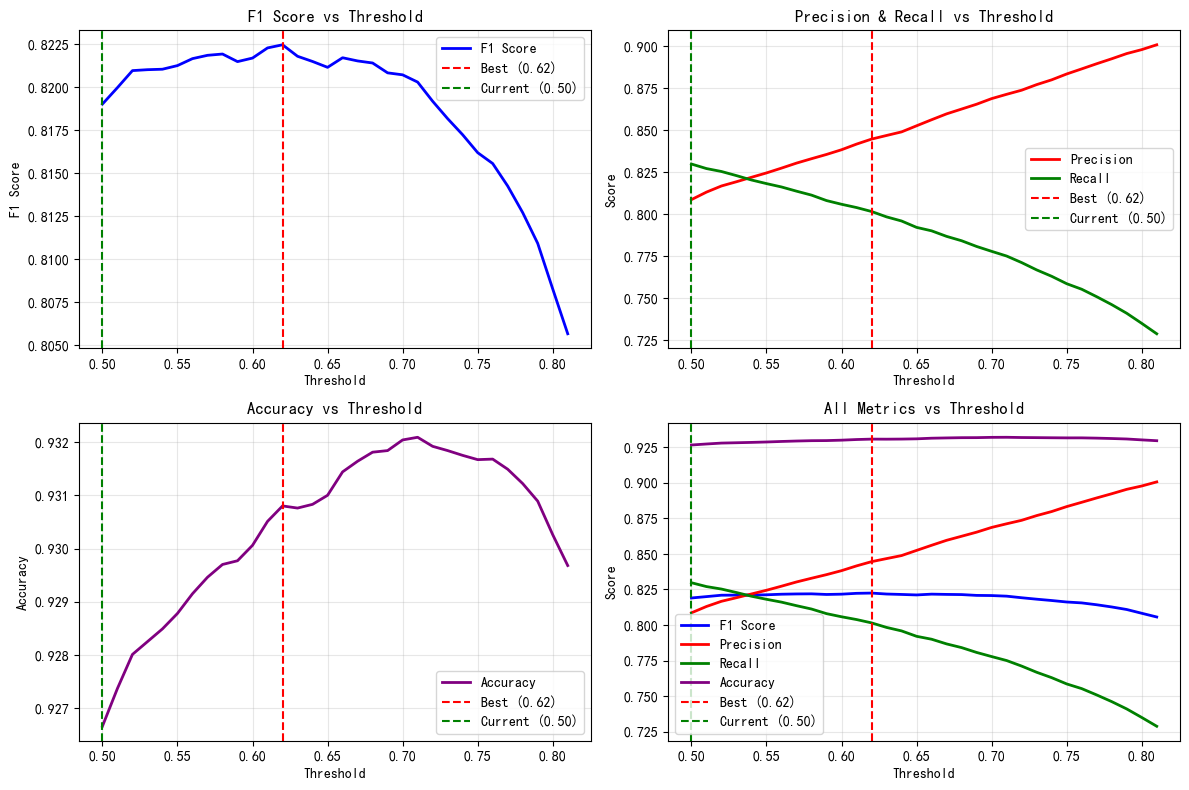


在最佳阈值 0.62 下的详细分类报告
              precision    recall  f1-score   support

     Class 0       0.95      0.96      0.96     80000
     Class 1       0.84      0.80      0.82     20000

    accuracy                           0.93    100000
   macro avg       0.90      0.88      0.89    100000
weighted avg       0.93      0.93      0.93    100000


ROC曲线对比分析
成功加载 NETCTL 数据集


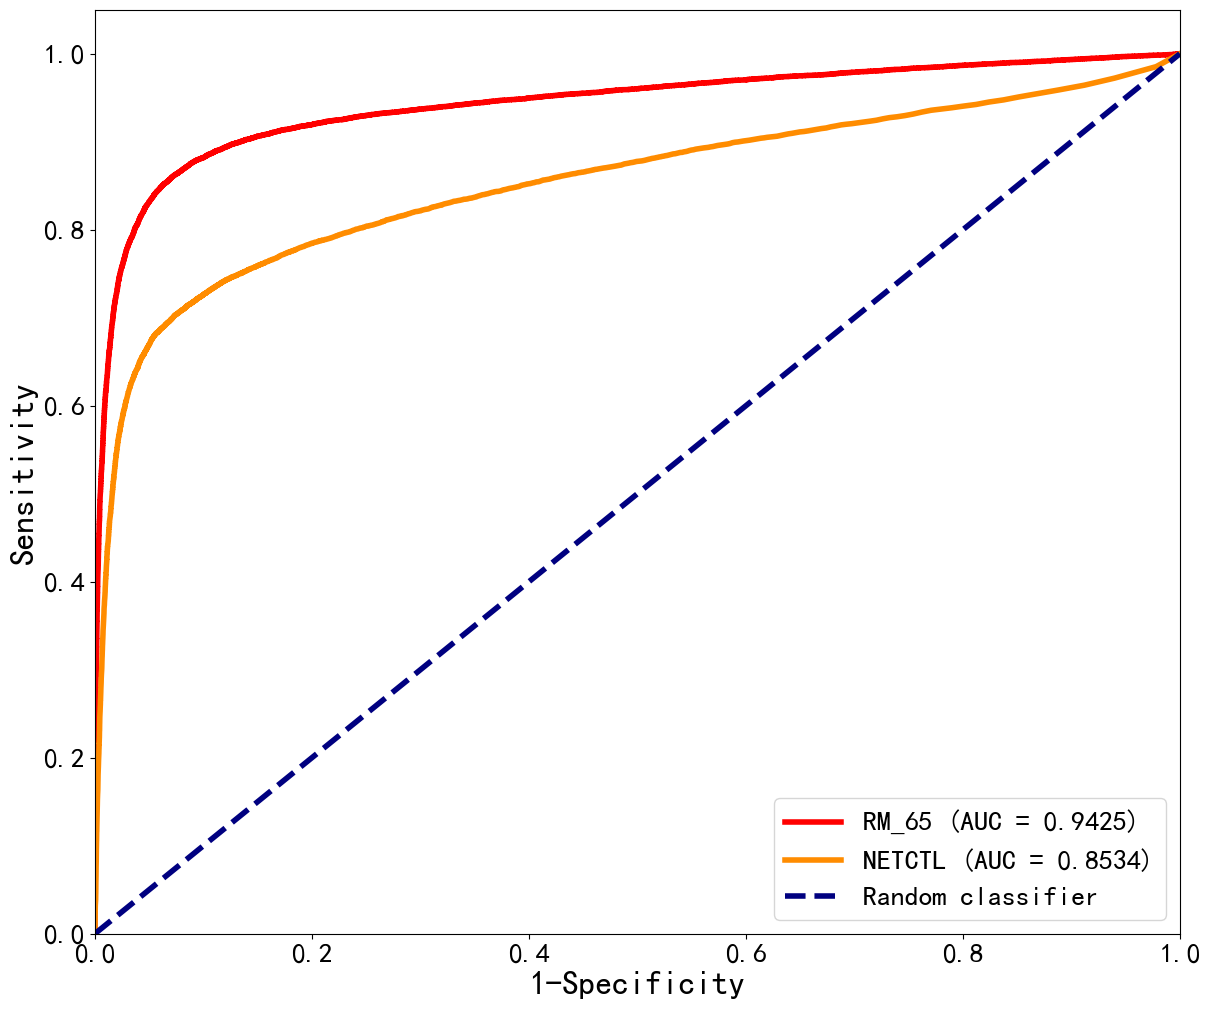


模型AUC值比较:
当前模型 AUC: 0.9425
NETCTL AUC: 0.8534

当前模型在最佳阈值 0.620 下的ROC性能:
  假阳性率 (FPR): 0.0368
  真阳性率 (TPR): 0.8015
  特异性: 0.9632
  灵敏度: 0.8015

NETCTL (最佳阈值=-8.623):
  准确率: 0.8370
  精确率: 0.5697
  召回率: 0.7555
  F1分数: 0.6496

当前模型 (最佳阈值=0.620):
  准确率: 0.9308
  精确率: 0.8446
  召回率: 0.8015
  F1分数: 0.8225

性能提升 (当前模型 vs NETCTL):
  准确率提升: +0.0938
  精确率提升: +0.2749
  召回率提升: +0.0460
  F1分数提升: +0.1729

ROC对比图已保存为: roc_curve_comparison.png 和 roc_curve_comparison.pdf

处理完成!
最佳阈值: 0.620
使用最佳阈值预测的结果已保存到: prediction_results_optimal_threshold_0.620.csv
阈值分析完整结果已保存到: threshold_analysis_complete_results.csv


In [4]:
#Prediction
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# 设置中文字体（如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('A0201_100000_test_predictions.csv')

# 提取预测概率和真实标签
y_scores = df['prediction_score'].values
y_true = df['label'].values

# 初始化变量来存储结果
results = []

# 测试不同的阈值
thresholds = np.arange(0.50, 0.81, 0.01)
print(f"正在测试 {len(thresholds)} 个阈值: {thresholds}")

for threshold in thresholds:
    # 根据阈值进行预测
    y_pred = (y_scores >= threshold).astype(int)
    
    # 计算指标
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # 计算混淆矩阵
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # 存储结果
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

# 创建结果DataFrame并按F1分数排序
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('f1_score', ascending=False)

# 找到最佳阈值
best_result = results_df_sorted.iloc[0]
best_threshold = best_result['threshold']

print("=" * 80)
print("阈值调优分析结果")
print("=" * 80)
print(f"测试的阈值数量: {len(thresholds)}")
print(f"阈值范围: {thresholds[0]:.2f} - {thresholds[-1]:.2f}")

# 显示所有阈值的结果概览
print(f"\n所有阈值结果概览:")
print(f"F1分数范围: {results_df['f1_score'].min():.4f} - {results_df['f1_score'].max():.4f}")
print(f"精确率范围: {results_df['precision'].min():.4f} - {results_df['precision'].max():.4f}")
print(f"召回率范围: {results_df['recall'].min():.4f} - {results_df['recall'].max():.4f}")

# 显示最佳结果
print(f"\n{'='*50}")
print("最佳阈值结果")
print(f"{'='*50}")
print(f"最佳阈值: {best_threshold:.2f}")
print(f"F1分数: {best_result['f1_score']:.4f}")
print(f"精确率: {best_result['precision']:.4f}")
print(f"召回率: {best_result['recall']:.4f}")
print(f"准确率: {best_result['accuracy']:.4f}")
print(f"混淆矩阵: TP={best_result['tp']}, FP={best_result['fp']}, TN={best_result['tn']}, FN={best_result['fn']}")

# 显示前10个最佳阈值
print(f"\n{'='*50}")
print("前10个最佳阈值 (按F1分数排序)")
print(f"{'='*50}")
top_10 = results_df_sorted.head(10)[['threshold', 'f1_score', 'precision', 'recall', 'accuracy']]
print(top_10.to_string(index=False, float_format='%.4f'))

# 显示当前0.5阈值的结果作为对比
current_threshold_05 = results_df[results_df['threshold'] == 0.50].iloc[0]
print(f"\n{'='*50}")
print("当前阈值(0.50)结果对比")
print(f"{'='*50}")
print(f"F1分数: {current_threshold_05['f1_score']:.4f}")
print(f"精确率: {current_threshold_05['precision']:.4f}")
print(f"召回率: {current_threshold_05['recall']:.4f}")
print(f"准确率: {current_threshold_05['accuracy']:.4f}")

# 计算改进程度
f1_improvement = best_result['f1_score'] - current_threshold_05['f1_score']
precision_improvement = best_result['precision'] - current_threshold_05['precision']
recall_improvement = best_result['recall'] - current_threshold_05['recall']

print(f"\n改进程度 (最佳阈值 vs 当前阈值0.50):")
print(f"F1分数提升: {f1_improvement:+.4f}")
print(f"精确率提升: {precision_improvement:+.4f}")
print(f"召回率提升: {recall_improvement:+.4f}")

# 保存完整结果
results_df.to_csv('threshold_analysis_complete_results.csv', index=False)
print(f"\n完整结果已保存到 'threshold_analysis_complete_results.csv'")

# =============================================================================
# 新增部分：使用最佳阈值重新预测并保存结果
# =============================================================================

print(f"\n{'='*50}")
print("使用最佳阈值重新预测并保存结果")
print(f"{'='*50}")

# 使用最佳阈值重新进行预测
optimal_predictions = (y_scores >= best_threshold).astype(int)

# 创建包含最佳阈值预测结果的新DataFrame
optimal_results_df = df.copy()
optimal_results_df['prediction_optimal'] = optimal_predictions
optimal_results_df['prediction_score'] = y_scores  # 保留原始分数

# 添加预测结果的文本描述
optimal_results_df['prediction_status'] = optimal_results_df['prediction_optimal'].map({
    0: '阴性',
    1: '阳性'
})

# 计算置信度级别
def get_confidence_level(score, threshold):
    if score >= threshold + 0.2:
        return '高置信度'
    elif score >= threshold + 0.1:
        return '中置信度'
    elif score >= threshold:
        return '低置信度'
    elif score >= threshold - 0.1:
        return '边界阴性'
    else:
        return '明确阴性'

optimal_results_df['confidence_level'] = optimal_results_df['prediction_score'].apply(
    lambda x: get_confidence_level(x, best_threshold)
)

# 保存使用最佳阈值预测的结果
optimal_output_file = f'prediction_results_optimal_threshold_{best_threshold:.3f}.csv'
optimal_results_df.to_csv(optimal_output_file, index=False, encoding='utf-8-sig')

print(f"使用最佳阈值 {best_threshold:.3f} 重新预测完成!")
print(f"重新预测的结果已保存到: {optimal_output_file}")

# 统计新预测结果
total_samples_optimal = len(optimal_results_df)
positive_count_optimal = optimal_results_df['prediction_optimal'].sum()
positive_ratio_optimal = (positive_count_optimal / total_samples_optimal) * 100

print(f"\n最佳阈值预测结果统计:")
print(f"总样本数: {total_samples_optimal}")
print(f"阳性预测数: {positive_count_optimal}")
print(f"阳性预测比例: {positive_ratio_optimal:.2f}%")

# 置信度分布统计
confidence_distribution = optimal_results_df['confidence_level'].value_counts()
print(f"\n置信度分布:")
for level, count in confidence_distribution.items():
    percentage = (count / total_samples_optimal) * 100
    print(f"  {level}: {count} 条序列 ({percentage:.1f}%)")

# 绘制性能随阈值变化的图表
plt.figure(figsize=(12, 8))

# F1分数
plt.subplot(2, 2, 1)
plt.plot(results_df['threshold'], results_df['f1_score'], 'b-', linewidth=2, label='F1 Score')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.axvline(x=0.50, color='g', linestyle='--', label='Current (0.50)')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# 精确率和召回率
plt.subplot(2, 2, 2)
plt.plot(results_df['threshold'], results_df['precision'], 'r-', linewidth=2, label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], 'g-', linewidth=2, label='Recall')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.axvline(x=0.50, color='g', linestyle='--', label='Current (0.50)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# 准确率
plt.subplot(2, 2, 3)
plt.plot(results_df['threshold'], results_df['accuracy'], 'purple', linewidth=2, label='Accuracy')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.axvline(x=0.50, color='g', linestyle='--', label='Current (0.50)')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# 所有指标在一起
plt.subplot(2, 2, 4)
plt.plot(results_df['threshold'], results_df['f1_score'], 'b-', linewidth=2, label='F1 Score')
plt.plot(results_df['threshold'], results_df['precision'], 'r-', linewidth=2, label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], 'g-', linewidth=2, label='Recall')
plt.plot(results_df['threshold'], results_df['accuracy'], 'purple', linewidth=2, label='Accuracy')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.axvline(x=0.50, color='g', linestyle='--', label='Current (0.50)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('All Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 使用最佳阈值生成详细分类报告
print(f"\n{'='*50}")
print(f"在最佳阈值 {best_threshold:.2f} 下的详细分类报告")
print(f"{'='*50}")
best_y_pred = (y_scores >= best_threshold).astype(int)
print(classification_report(y_true, best_y_pred, target_names=['Class 0', 'Class 1']))

# =============================================================================
# 新增部分：生成ROC曲线并与其他模型对比
# =============================================================================

print(f"\n{'='*50}")
print("ROC曲线对比分析")
print(f"{'='*50}")

# 读取其他模型的数据用于对比
try:
    # 读取第一个数据文件（NETCTL）
    df1 = pd.read_csv('net_100000_updated.csv')
    print("成功加载 NETCTL 数据集")
    
    # 提取第一个数据集的预测分数和真实标签（需要反转分数）
    y_scores1 = 1 - df1['Rank'].values
    y_true1 = df1['label'].values
    
    # 计算当前模型和其他模型的ROC曲线
    fpr_current, tpr_current, thresholds_current = roc_curve(y_true, y_scores)
    roc_auc_current = auc(fpr_current, tpr_current)
    
    fpr1, tpr1, thresholds1 = roc_curve(y_true1, y_scores1)
    roc_auc1 = auc(fpr1, tpr1)
    
    # 绘制合并的ROC曲线
    plt.figure(figsize=(14, 12))
    
    # 绘制当前模型的ROC曲线
    plt.plot(fpr_current, tpr_current, color='red', lw=4,
             label=f'RM_65 (AUC = {roc_auc_current:.4f})')
    
    # 绘制第一条ROC曲线（NETCTL）
    plt.plot(fpr1, tpr1, color='darkorange', lw=4,
             label=f'NETCTL (AUC = {roc_auc1:.4f})')
    
    # 绘制随机分类器参考线
    plt.plot([0, 1], [0, 1], color='navy', lw=4, linestyle='--',
             label='Random classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('1-Specificity', fontsize=24)
    plt.ylabel('Sensitivity', fontsize=24)
    plt.legend(loc="lower right", fontsize=20)
    plt.grid(False)
    
    # 设置坐标轴刻度字体大小
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    # 保存图片
    plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig('roc_curve_comparison.pdf', bbox_inches='tight')
    
    plt.show()
    
    # 打印AUC值比较
    print(f"\n模型AUC值比较:")
    print(f"当前模型 AUC: {roc_auc_current:.4f}")
    print(f"NETCTL AUC: {roc_auc1:.4f}")
    
    # 分析当前模型在最佳阈值下的ROC性能
    print(f"\n当前模型在最佳阈值 {best_threshold:.3f} 下的ROC性能:")
    # 找到最接近最佳阈值的ROC点
    threshold_idx = np.argmin(np.abs(thresholds_current - best_threshold))
    if threshold_idx < len(fpr_current):
        fpr_at_best = fpr_current[threshold_idx]
        tpr_at_best = tpr_current[threshold_idx]
        print(f"  假阳性率 (FPR): {fpr_at_best:.4f}")
        print(f"  真阳性率 (TPR): {tpr_at_best:.4f}")
        print(f"  特异性: {1-fpr_at_best:.4f}")
        print(f"  灵敏度: {tpr_at_best:.4f}")
    
    # 分析NETCTL在最佳阈值下
    distances1 = np.sqrt(fpr1**2 + (1-tpr1)**2)
    optimal_idx1 = np.argmin(distances1)
    optimal_threshold1 = thresholds1[optimal_idx1]
    
    y_pred1 = (y_scores1 >= optimal_threshold1).astype(int)
    tn1, fp1, fn1, tp1 = confusion_matrix(y_true1, y_pred1).ravel()
    
    accuracy1 = (tp1 + tn1) / (tp1 + tn1 + fp1 + fn1)
    precision1 = tp1 / (tp1 + fp1) if (tp1 + fp1) > 0 else 0
    recall1 = tp1 / (tp1 + fn1) if (tp1 + fn1) > 0 else 0
    f1_1 = 2 * precision1 * recall1 / (precision1 + recall1) if (precision1 + recall1) > 0 else 0
    
    print(f"\nNETCTL (最佳阈值={optimal_threshold1:.3f}):")
    print(f"  准确率: {accuracy1:.4f}")
    print(f"  精确率: {precision1:.4f}")
    print(f"  召回率: {recall1:.4f}")
    print(f"  F1分数: {f1_1:.4f}")
    
    # 当前模型在最佳阈值下的性能
    print(f"\n当前模型 (最佳阈值={best_threshold:.3f}):")
    print(f"  准确率: {best_result['accuracy']:.4f}")
    print(f"  精确率: {best_result['precision']:.4f}")
    print(f"  召回率: {best_result['recall']:.4f}")
    print(f"  F1分数: {best_result['f1_score']:.4f}")
    
    # 性能提升分析
    accuracy_improvement = best_result['accuracy'] - accuracy1
    precision_improvement_vs_netctl = best_result['precision'] - precision1
    recall_improvement_vs_netctl = best_result['recall'] - recall1
    f1_improvement_vs_netctl = best_result['f1_score'] - f1_1
    
    print(f"\n性能提升 (当前模型 vs NETCTL):")
    print(f"  准确率提升: {accuracy_improvement:+.4f}")
    print(f"  精确率提升: {precision_improvement_vs_netctl:+.4f}")
    print(f"  召回率提升: {recall_improvement_vs_netctl:+.4f}")
    print(f"  F1分数提升: {f1_improvement_vs_netctl:+.4f}")
    
    print(f"\nROC对比图已保存为: roc_curve_comparison.png 和 roc_curve_comparison.pdf")

except Exception as e:
    print(f"无法加载NETCTL模型数据: {e}")
    print("将只绘制当前模型的ROC曲线")
    
    # 只绘制当前模型的ROC曲线
    fpr_current, tpr_current, thresholds_current = roc_curve(y_true, y_scores)
    roc_auc_current = auc(fpr_current, tpr_current)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_current, tpr_current, color='red', lw=2,
             label=f'Current Model (AUC = {roc_auc_current:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('1-Specificity')
    plt.ylabel('Sensitivity')
    plt.title('ROC Curve - Current Model')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    plt.savefig('current_model_roc.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"当前模型 AUC: {roc_auc_current:.4f}")

print(f"\n{'='*50}")
print("处理完成!")
print(f"{'='*50}")
print(f"最佳阈值: {best_threshold:.3f}")
print(f"使用最佳阈值预测的结果已保存到: {optimal_output_file}")
print(f"阈值分析完整结果已保存到: threshold_analysis_complete_results.csv")